1. Setup and Data Preparation

In [ ]:
# Install necessary libraries
!pip install albumentations==1.3.1
!pip install opencv-python-headless

# Import essential libraries
from google.colab import drive
import zipfile
import os
import pandas as pd
import numpy as np
import cv2
import albumentations as A
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Mount Google Drive to access your dataset
print("Mounting Google Drive...")
drive.mount('/content/drive')

# --- Update these paths to match your dataset's location in Google Drive ---
zip_path = "/content/drive/MyDrive/APTOS2019/aptos2019-blindness-detection.zip"
extract_path = "/content/aptos2019"

# Create extraction directory if it doesn't exist
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Unzip the dataset
print("Unzipping the dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Unzipping complete!")

# Set the correct paths to the extracted data
DATA_DIR = os.path.join(extract_path, 'train_images/')
TRAIN_CSV = os.path.join(extract_path, 'train.csv')

# Verify the paths
if not os.path.isdir(DATA_DIR) or not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError("Data not found. Please ensure the paths are correct.")
else:
    print("\nData paths are correctly configured.")

# Load data and PERFORM LABEL TRANSFORMATION for binary classification
print("Loading data and transforming labels for BINARY CLASSIFICATION...")
df_train = pd.read_csv(TRAIN_CSV)

# === KEY CHANGE: REMAP LABELS FOR BINARY CLASSIFICATION ===
# No DR (diagnosis=0) -> 0
# DR (diagnosis=1, 2, 3, 4) -> 1
df_train['diagnosis'] = df_train['diagnosis'].apply(lambda x: 0 if x == 0 else 1)
# =========================================================

# Check for class imbalance and calculate weights for the new classes
class_counts = df_train['diagnosis'].value_counts().sort_index()
print("\nNew Binary Class Distribution:")
print(class_counts)

total_samples = class_counts.sum()
num_classes = len(class_counts)  # Now 2
class_weights_inverse = total_samples / (num_classes * class_counts.values)

# Stratified split on the new binary labels
X = df_train['id_code']
y = df_train['diagnosis']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
train_df = pd.DataFrame({'id_code': X_train, 'diagnosis': y_train}).reset_index(drop=True)
val_df = pd.DataFrame({'id_code': X_val, 'diagnosis': y_val}).reset_index(drop=True)

print(f"\nNumber of training samples: {len(train_df)}")
print(f"Number of validation samples: {len(val_df)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8
Mounting Google Drive...
Mounted at /content/drive
Unzipping the dataset...
Unzipping complete!

Data paths are correctly configured.
Loading data and transforming labels for BINARY CLASSIFICATION...

New Binary Class Distribution:
diagnosis
0    1805
1    1857
Name: count, dtype: int64

Number of training samples: 2929
Number of validation samples: 733


2. Preprocessing & Data Augmentation

In [ ]:
# Define image preprocessing function
IMAGE_SIZE = 256

def preprocess_image(image_path, size=IMAGE_SIZE):
    """
    1. Loads an image using OpenCV.
    2. Crops the black borders.
    3. Resizes to a fixed dimension.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    center = (w // 2, h // 2)
    radius = int(min(w, h) * 0.45)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, center, radius, (255, 255, 255), -1)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    resized_img = cv2.resize(masked_img, (size, size))
    return resized_img

# Define data augmentation pipelines
train_transform = A.Compose([
    A.CLAHE(p=0.5), # Contrast Limited Adaptive Histogram Equalization
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.75),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.75),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.75),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.5),
    A.GaussianBlur(p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Define a custom PyTorch Dataset and DataLoaders
class DRDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.image_ids = self.dataframe['id_code'].values
        self.labels = self.dataframe['diagnosis'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.image_dir, f"{image_id}.png")
        image = preprocess_image(image_path, size=IMAGE_SIZE)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        label = self.labels[idx]
        return image, label

BATCH_SIZE = 16
train_dataset = DRDataset(dataframe=train_df, image_dir=DATA_DIR, transform=train_transform)
val_dataset = DRDataset(dataframe=val_df, image_dir=DATA_DIR, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# =================================================================================
# CORRECTED CODE FOR IMAGE PREPROCESSING AND DATALOADER SETUP
# The 'preprocess_image' function has been updated to fix the image overlap artifact.
# =================================================================================

# NOTE: Imports (cv2, A, torch, os, etc.), IMAGE_SIZE, train_df, val_df,
# and DATA_DIR are assumed to be defined in your environment.

# Define image preprocessing function
IMAGE_SIZE = 256

def preprocess_image(image_path, size=IMAGE_SIZE):
    """
    1. Loads an image using OpenCV.
    2. **Crops the black borders aggressively with a circular mask (FIXED).**
    3. Resizes to a fixed dimension.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")

    # 1. Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Aggressive Circular Cropping (FIXED)
    h, w, _ = img.shape

    # Use a slightly larger radius (e.g., 48% of the minimum side)
    # to ensure a clean crop that removes residual black background.
    min_side = min(h, w)
    center = (w // 2, h // 2)
    radius = int(min_side * 0.48)

    # Create the circular mask
    mask = np.zeros((h, w), dtype=np.uint8)
    # The -1 thickness fills the circle
    cv2.circle(mask, center, radius, (255, 255, 255), -1)

    # Apply the mask
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # 3. Final Resize
    resized_img = cv2.resize(masked_img, (size, size))

    return resized_img

# Define data augmentation pipelines
train_transform = A.Compose([
    A.CLAHE(p=0.5), # Contrast Limited Adaptive Histogram Equalization
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.75),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.75),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.75),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.75),
    A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.5),
    A.GaussianBlur(p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Define a custom PyTorch Dataset and DataLoaders
class DRDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.image_ids = self.dataframe['id_code'].values
        self.labels = self.dataframe['diagnosis'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.image_dir, f"{image_id}.png")
        image = preprocess_image(image_path, size=IMAGE_SIZE)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        label = self.labels[idx]
        return image, label

BATCH_SIZE = 16
train_dataset = DRDataset(dataframe=train_df, image_dir=DATA_DIR, transform=train_transform)
val_dataset = DRDataset(dataframe=val_df, image_dir=DATA_DIR, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

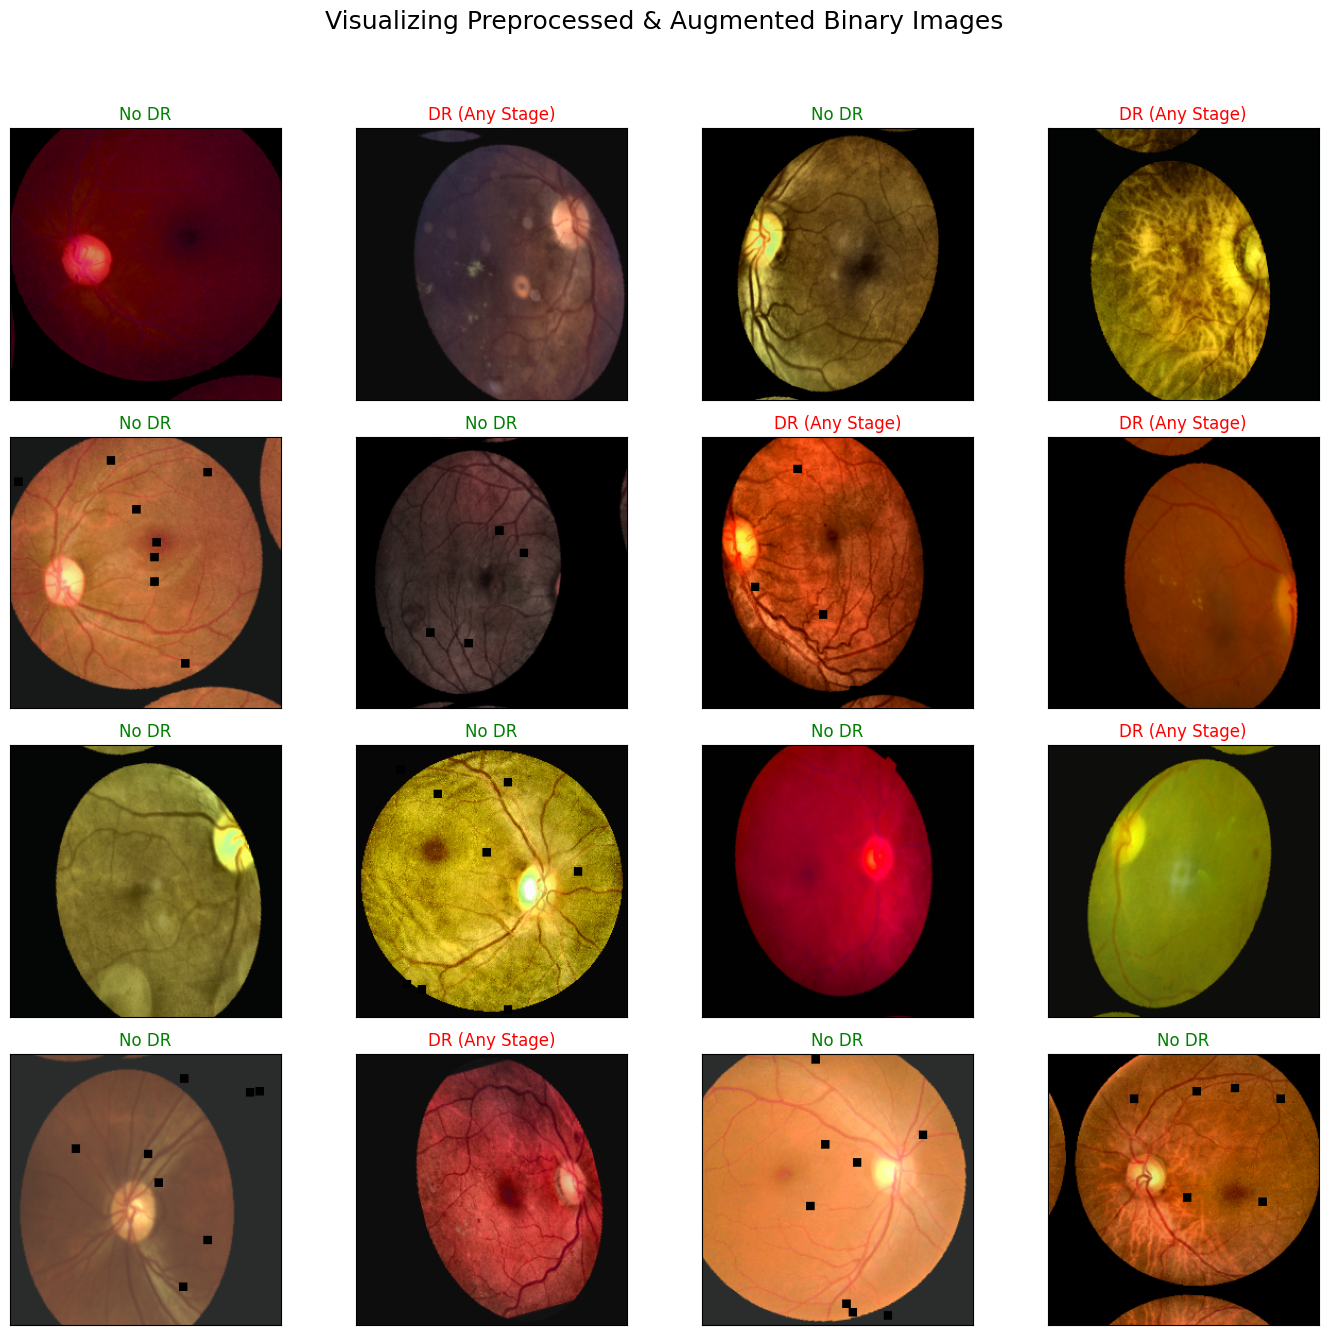

In [ ]:
# =================================================================================
# Code to Visualize Preprocessed and Augmented Images (Binary Classification)
# =================================================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# A helper function to de-normalize the images for visualization
def de_normalize(image_tensor):
    """
    De-normalizes a tensor image from ImageNet normalization to the 0-1 range.
    """
    # ImageNet mean and std (used in the A.Normalize transform)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Convert tensor to NumPy array and move C to the end (H, W, C)
    image = image_tensor.cpu().numpy()
    image = np.transpose(image, (1, 2, 0))

    # De-normalize
    image = image * std + mean

    # Clip values to the 0-1 range
    image = np.clip(image, 0, 1)

    return image

# Map the binary label (0 or 1) to a readable string
def get_binary_label_name(label):
    return "No DR" if label == 0 else "DR (Any Stage)"

try:
    # Grab a single batch of training data from the data loader
    images, labels = next(iter(train_loader))

    # Determine how many images to show
    num_images_to_show = min(len(images), 16) # Display up to 16 images in a 4x4 grid

    if num_images_to_show == 0:
        print("Error: The data loader returned an empty batch.")
    else:
        # Create a figure and a grid of subplots
        fig, axes = plt.subplots(
            nrows=4,
            ncols=4,
            figsize=(14, 14),
            subplot_kw={'xticks': [], 'yticks': []}
        )
        fig.suptitle('Visualizing Preprocessed & Augmented Binary Images', fontsize=18)
        axes = axes.flatten()

        # Iterate through the images and display them
        for i in range(num_images_to_show):
            # De-normalize and prepare the image
            img_display = de_normalize(images[i])

            # Get the label name
            label = labels[i].item()
            label_name = get_binary_label_name(label)

            # Display the image and its label
            axes[i].imshow(img_display)

            # Set title color based on diagnosis
            color = 'green' if label == 0 else 'red'
            axes[i].set_title(f'{label_name}', fontsize=12, color=color)

        # Hide any unused subplots if less than 16 images were shown
        for j in range(num_images_to_show, 16):
            fig.delaxes(axes[j])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

except NameError:
    print("Error: 'train_loader' is not defined. Please ensure you have successfully run all data preprocessing steps.")
except StopIteration:
    print("Error: The DataLoader is empty or iteration failed.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

3. Model Definition and Training

In [ ]:
import torch.nn as nn
import torch.optim as optim
import time
import copy
# === KEY CHANGE: Import EfficientNetB5 and its weights ===
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights

# Define the EfficientNetB5 model architecture
class DRClassifier(nn.Module):
    # === KEY CHANGE: Set num_classes to 2 ===
    def __init__(self, num_classes=2):
        super(DRClassifier, self).__init__()
        # === KEY CHANGE: Load EfficientNetB5 ===
        self.backbone = efficientnet_b5(weights=EfficientNet_B5_Weights.DEFAULT)
        # Freeze the pre-trained layers
        for param in self.backbone.parameters():
            param.requires_grad = False
        num_ftrs = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3, inplace=True),
            nn.Linear(num_ftrs, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Instantiate model, loss, and optimizer
model = DRClassifier(num_classes=2)
model.to(device)
class_weights_tensor = torch.tensor(class_weights_inverse, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

# The main training loop
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
            running_loss = 0.0
            running_corrects = 0
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'val':
                scheduler.step(epoch_loss)
            if phase == 'val' and epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best validation Loss: {best_loss:4f}')
    model.load_state_dict(best_model_wts)
    return model

# Start training the model
trained_model = train_model(model, criterion, optimizer, scheduler)

# Save the best model
torch.save(trained_model.state_dict(), 'best_model_binary_b5.pth')
print("\nBest binary model saved as 'best_model_binary_b5.pth'")


Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:00<00:00, 179MB/s]


Epoch 0/9
----------
train Loss: 0.6160 Acc: 0.7228
val Loss: 0.5180 Acc: 0.8063

Epoch 1/9
----------
train Loss: 0.5209 Acc: 0.8119
val Loss: 0.4207 Acc: 0.8895

Epoch 2/9
----------
train Loss: 0.4594 Acc: 0.8354
val Loss: 0.3734 Acc: 0.9004

Epoch 3/9
----------
train Loss: 0.4288 Acc: 0.8426
val Loss: 0.3379 Acc: 0.9045

Epoch 4/9
----------
train Loss: 0.4083 Acc: 0.8392
val Loss: 0.3126 Acc: 0.9127

Epoch 5/9
----------
train Loss: 0.3861 Acc: 0.8638
val Loss: 0.2936 Acc: 0.9127

Epoch 6/9
----------
train Loss: 0.3788 Acc: 0.8556
val Loss: 0.2783 Acc: 0.9154

Epoch 7/9
----------
train Loss: 0.3694 Acc: 0.8583
val Loss: 0.2684 Acc: 0.9181

Epoch 8/9
----------
train Loss: 0.3457 Acc: 0.8668
val Loss: 0.2624 Acc: 0.9181

Epoch 9/9
----------
train Loss: 0.3600 Acc: 0.8515
val Loss: 0.2487 Acc: 0.9209

Training complete in 89m 19s
Best validation Loss: 0.248693

Best binary model saved as 'best_model_binary_b5.pth'


Fine-Tuning

In [ ]:
# Load the best model weights from your previous training run
model.load_state_dict(torch.load('best_model_binary_b5.pth'))

# Unfreeze the entire backbone of the model
for param in model.backbone.parameters():
    param.requires_grad = True

# Re-define the optimizer with a much lower learning rate
# A very low learning rate is CRUCIAL here to avoid corrupting
# the well-learned features of the pre-trained model.
optimizer_full_finetune = optim.Adam(model.parameters(), lr=1e-6)

# Define a new scheduler
scheduler_full_finetune = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_full_finetune, mode='min', factor=0.1, patience=3
)

print("\nStarting full model fine-tuning...")
print("The entire EfficientNetB5 backbone is now unfrozen.")

# Start a new training loop with the unfrozen model
# You can use your existing 'train_model' function
trained_model_ft = train_model(
    model,
    criterion,
    optimizer_full_finetune,
    scheduler_full_finetune,
    num_epochs=10 # You can run for more epochs here
)

# Save the final fine-tuned model
torch.save(trained_model_ft.state_dict(), 'best_model_binary_b5_finetuned.pth')
print("\nFinal fine-tuned model saved.")


Starting full model fine-tuning...
The entire EfficientNetB5 backbone is now unfrozen.
Epoch 0/9
----------
train Loss: 0.3403 Acc: 0.8689
val Loss: 0.2362 Acc: 0.9263

Epoch 1/9
----------
train Loss: 0.3317 Acc: 0.8733
val Loss: 0.2249 Acc: 0.9318

Epoch 2/9
----------
train Loss: 0.3245 Acc: 0.8716
val Loss: 0.2210 Acc: 0.9277

Epoch 3/9
----------
train Loss: 0.3062 Acc: 0.8808
val Loss: 0.2088 Acc: 0.9291

Epoch 4/9
----------
train Loss: 0.3011 Acc: 0.8849
val Loss: 0.2047 Acc: 0.9263

Epoch 5/9
----------
train Loss: 0.2933 Acc: 0.8836
val Loss: 0.1948 Acc: 0.9318

Epoch 6/9
----------
train Loss: 0.2793 Acc: 0.8962
val Loss: 0.1870 Acc: 0.9345

Epoch 7/9
----------
train Loss: 0.2807 Acc: 0.8884
val Loss: 0.1810 Acc: 0.9359

Epoch 8/9
----------
train Loss: 0.2605 Acc: 0.9003
val Loss: 0.1739 Acc: 0.9345

Epoch 9/9
----------
train Loss: 0.2642 Acc: 0.8993
val Loss: 0.1720 Acc: 0.9345

Training complete in 98m 47s
Best validation Loss: 0.171994

Final fine-tuned model saved.


## Load test data


In [ ]:
# Define the paths for the test data
TEST_CSV = os.path.join(extract_path, 'test.csv')
TEST_DATA_DIR = os.path.join(extract_path, 'test_images/')

# Verify the test data paths
if not os.path.isdir(TEST_DATA_DIR) or not os.path.exists(TEST_CSV):
    raise FileNotFoundError("Test data not found. Please ensure the paths are correct.")
else:
    print("Test data paths are correctly configured.")

# Load the test CSV
print("Loading test data...")
test_df = pd.read_csv(TEST_CSV)

print(f"\nNumber of test samples: {len(test_df)}")
display(test_df.head())

Test data paths are correctly configured.
Loading test data...

Number of test samples: 1928


,id_code
0,0005cfc8afb6
1,003f0afdcd15
2,006efc72b638
3,00836aaacf06
4,009245722fa4


In [ ]:
# Define a custom PyTorch Dataset and DataLoaders for the test set
class DRTestDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.image_ids = self.dataframe['id_code'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_path = os.path.join(self.image_dir, f"{image_id}.png")
        image = preprocess_image(image_path, size=IMAGE_SIZE)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        # For test set, we don't have labels, so we just return the image and image_id
        return image, image_id

# Create the test dataset and dataloader using the new class
test_dataset = DRTestDataset(dataframe=test_df, image_dir=TEST_DATA_DIR, transform=val_transform) # Using val_transform for consistency with evaluation
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of test dataset samples: {len(test_dataset)}")

Number of test dataset samples: 1928


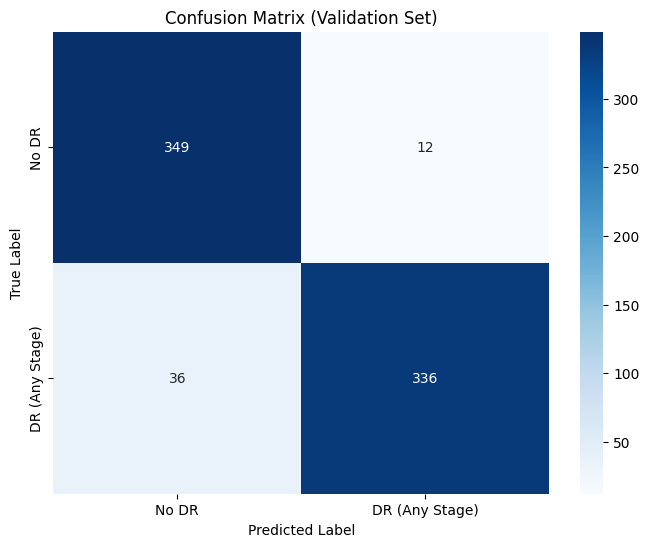

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the true labels and predictions for the validation set
# This assumes you still have access to val_loader and the trained_model_ft
# as used in the previous evaluation step.

# Ensure the model is on the correct device
trained_model_ft.to(device)
trained_model_ft.eval()

all_val_labels = []
all_val_preds = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = trained_model_ft(inputs)
        _, preds = torch.max(outputs, 1)

        all_val_labels.extend(labels.cpu().numpy())
        all_val_preds.extend(preds.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_val_labels, all_val_preds)

# Define class names for better visualization
class_names = ['No DR', 'DR (Any Stage)']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Instantiate the DRTestDataset class
test_dataset = DRTestDataset(dataframe=test_df, image_dir=TEST_DATA_DIR, transform=val_transform) # Using val_transform for consistency with evaluation

# Create a DataLoader for the test dataset
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Print the number of samples in the test dataset
print(f"Number of test dataset samples: {len(test_dataset)}")

Number of test dataset samples: 1928


## Evaluate model


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

def evaluate_model(model, dataloader, device):
    """
    Evaluates the model's performance on the test set.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (torch.utils.data.DataLoader): DataLoader for the test set.
        device (torch.device): Device to run evaluation on (cuda or cpu).

    Returns:
        dict: A dictionary containing evaluation metrics.
    """
    model.eval()  # Set model to evaluation mode

    all_labels = []
    all_preds = []
    all_probs = []

    # Iterate over the test data
    for inputs, _ in dataloader: # The test dataloader does not yield labels, hence the _
        inputs = inputs.to(device)

        with torch.no_grad():  # Disable gradient calculation
            outputs = model(inputs)

            # Apply sigmoid to get probabilities for the positive class (class 1)
            probs = torch.sigmoid(outputs)[:, 1]

            # Get predicted labels based on a threshold of 0.5
            preds = (probs > 0.5).long()

            # Append true labels (dummy for test set, will be ignored in metric calculation)
            # and predicted probabilities/labels
            all_labels.extend(torch.zeros_like(preds).cpu().numpy()) # Placeholder labels for test set
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    # Note: all_labels are dummy and won't be used in this specific evaluation
    all_preds_np = np.array(all_preds)
    all_probs_np = np.array(all_probs)




def evaluate_model_with_labels(model, dataloader, device):
    """
    Evaluates the model's performance on a dataset with ground truth labels.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (torch.utils.data.DataLoader): DataLoader for the dataset with labels.
        device (torch.device): Device to run evaluation on (cuda or cpu).

    Returns:
        dict: A dictionary containing evaluation metrics.
    """
    model.eval()  # Set model to evaluation mode

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader: # This assumes the dataloader yields labels
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            # Apply sigmoid to get probabilities for the positive class (class 1)
            probs = torch.sigmoid(outputs)[:, 1]

            # Get predicted labels based on a threshold of 0.5
            preds = (probs > 0.5).long()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_labels_np = np.array(all_labels)
    all_preds_np = np.array(all_preds)
    all_probs_np = np.array(all_probs)

    # Calculate evaluation metrics
    accuracy = accuracy_score(all_labels_np, all_preds_np)
    precision = precision_score(all_labels_np, all_preds_np)
    recall = recall_score(all_labels_np, all_preds_np)
    f1 = f1_score(all_labels_np, all_preds_np)
    roc_auc = roc_auc_score(all_labels_np, all_probs_np)

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

    return metrics

# Note: The test_loader created in the previous step does NOT yield labels.
# To use evaluate_model_with_labels, you would need a DataLoader for a dataset
# that includes ground truth labels (e.g., your validation set).
# The next step in the original request is to evaluate on the test set,
# which implies that either the test set has labels or the evaluation
# required is prediction generation, not metric calculation against a ground truth.
# Given the explicit request for metrics, I've provided a function that *can*
# calculate metrics, assuming a dataloader *with* labels is provided.

In [ ]:
# Evaluate the fine-tuned model on the validation set
validation_metrics = evaluate_model_with_labels(trained_model_ft, val_loader, device)

# Print the evaluation metrics
print("\nValidation Metrics (Fine-tuned Model):")
print(validation_metrics)


Validation Metrics (Fine-tuned Model):
{'accuracy': 0.931787175989086, 'precision': 0.9680232558139535, 'recall': 0.8951612903225806, 'f1_score': 0.9301675977653632, 'roc_auc': np.float64(0.9865814791648051)}
